# Task 1: 基于深度特征的图像聚类分析

## 实验概述

本实验旨在利用深度学习预训练模型提取图像特征，并使用聚类算法对图像进行无监督分类。

### 实验目标

1. 使用ResNet50预训练模型提取图像的深度特征
2. 应用K-means聚类算法对600张图像进行聚类
3. 评估聚类效果并与真实标签进行对比
4. 可视化聚类结果

### 实验流程

```
数据加载 → 特征提取(ResNet50) → K-means聚类 → 评估(ARI/NMI) → 可视化(t-SNE)
```

## 0. 安装依赖包

首先安装必要的Python库：


In [1]:
!pip install opencv-python pillow torch torchvision matplotlib scikit-learn seaborn
print('install finished')

install finished


## 1. 导入必要的库

### 库说明

本实验需要以下Python库：

- **numpy**: 数值计算库
- **json**: JSON文件处理
- **PIL (Pillow)**: 图像加载和处理
- **matplotlib & seaborn**: 数据可视化
- **torch & torchvision**: 深度学习框架和预训练模型
- **sklearn**: 
  - `KMeans`: K-means聚类算法
  - `adjusted_rand_score`, `normalized_mutual_info_score`: 聚类评估指标
  - `confusion_matrix`: 混淆矩阵
  - `TSNE`: t-SNE降维可视化


In [2]:
import os
import numpy as np
import json
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
from sklearn.manifold import TSNE

print("所有库导入成功！")

所有库导入成功！


## 2. 加载真实标签数据

### 数据集说明

本实验使用工业产品图像数据集，包含6个类别的产品图像：
- **bottle**：瓶子
- **cable**：电缆
- **leather**：皮革
- **pill**：药片
- **tile**：瓷砖
- **transistor**：晶体管

### 标签文件格式

`cluster_labels.json` 文件存储了每张图片的真实类别标签：
```json
{
  "001.png": "transistor",
  "002.png": "leather",
  ...
}
```

### 数据加载步骤

1. 读取JSON格式的标签文件
2. 检查数据集大小和类别分布
3. 为后续聚类评估准备真实标签


In [3]:
# 加载JSON文件中的真实标签
with open('cluster_labels.json', 'r') as f:
    label_dict = json.load(f)

# 打印前几个标签,检查文件路径是否正确
print("前10个图片的真实标签：")
for i, (img_name, true_label) in enumerate(list(label_dict.items())[:10]):
    print(f"{img_name}: {true_label}")

print(f"\n总共有 {len(label_dict)} 张图片，{len(set(label_dict.values()))} 个类别")
print("类别包括:", sorted(set(label_dict.values())))

前10个图片的真实标签：
001.png: transistor
002.png: leather
003.png: pill
004.png: bottle
005.png: transistor
006.png: bottle
007.png: tile
008.png: pill
009.png: transistor
010.png: transistor

总共有 600 张图片，6 个类别
类别包括: ['bottle', 'cable', 'leather', 'pill', 'tile', 'transistor']


## 3. 深度特征提取 - ResNet50预训练模型

### ResNet网络架构

ResNet（Residual Network）通过引入残差连接解决了深层网络的梯度消失问题。

**残差块**：
$$y = F(x, \{W_i\}) + x$$

其中 $F(x)$ 是要学习的残差映射，而不是直接学习目标映射 $H(x)$。

### ResNet50结构

- 总层数：50层
- 主要组件：卷积层、批归一化、ReLU激活、残差连接
- 全局平均池化后输出：2048维特征向量

### 预训练模型的优势

使用在ImageNet上预训练的ResNet50作为特征提取器：
1. **迁移学习**：利用在大规模数据集上学到的通用特征
2. **减少训练时间**：不需要从头训练深度网络
3. **提升性能**：预训练权重包含丰富的视觉特征表示

### 图像预处理流程

为了与ResNet50的训练要求一致，需要对图像进行标准化处理：

1. **调整大小**：将图像缩放到256×256像素
2. **中心裁剪**：裁剪中心224×224区域
3. **转换为Tensor**：将PIL图像转换为PyTorch张量
4. **标准化**：使用ImageNet数据集的均值和标准差
   
   $$x_{normalized} = \frac{x - \mu}{\sigma}$$
   
   其中：
   - $\mu = [0.485, 0.456, 0.406]$ （RGB通道均值）
   - $\sigma = [0.229, 0.224, 0.225]$ （RGB通道标准差）

### 特征提取过程

对每张图片：
1. 加载图像并转换为RGB格式
2. 应用预处理流程
3. 通过ResNet50前向传播（不计算梯度）
4. 提取全局平均池化后的2048维特征向量
5. 保存特征和对应的真实标签


In [4]:
# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 加载预训练模型
model = models.resnet50(pretrained=True)
model = torch.nn.Sequential(*(list(model.children())[:-1]))
model = model.to(device)
model.eval()

# 图像预处理
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 确保图片顺序与JSON中的顺序一致
image_dir = "dataset"
image_names = sorted(os.listdir(image_dir))  # 按文件名排序，确保顺序一致
features_list = []
true_labels = []  # 存储真实标签

print("开始提取图片特征...")
for i, img_name in enumerate(image_names):
    if img_name not in label_dict:
        print(f"警告: {img_name} 不在标签文件中，跳过")
        continue
        
    try:
        image_path = os.path.join(image_dir, img_name)
        image = Image.open(image_path).convert('RGB')
        input_tensor = preprocess(image).unsqueeze(0).to(device)
        
        with torch.no_grad():
            features = model(input_tensor)
            features_list.append(features.cpu().numpy().flatten())
            true_labels.append(label_dict[img_name])  # 保存对应的真实标签
            
        if (i + 1) % 50 == 0:  # 每50张图片打印一次进度
            print(f"已处理 {i + 1} 张图片...")
            
    except Exception as e:
        print(f"处理图片 {img_name} 时出错: {e}")

# 转换为NumPy数组
X = np.array(features_list)
print(f"特征提取完成！共提取了 {X.shape[0]} 张图片的特征")

使用设备: cpu


C:\ProgramData\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


开始提取图片特征...
已处理 50 张图片...
已处理 100 张图片...
已处理 150 张图片...
已处理 200 张图片...
已处理 250 张图片...
已处理 300 张图片...
已处理 350 张图片...
已处理 400 张图片...
已处理 450 张图片...
已处理 500 张图片...
已处理 550 张图片...
已处理 600 张图片...
特征提取完成！共提取了 600 张图片的特征


## 4. K-means聚类算法

### 算法原理

K-means是一种基于划分的聚类算法，目标是将n个样本分成k个簇，使得簇内平方误差和（SSE）最小：

$$SSE = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

其中：
- $C_i$: 第i个簇
- $\mu_i$: 第i个簇的质心（簇内所有点的平均值）
- $||x - \mu_i||^2$: 样本x到质心的欧氏距离平方

### 算法流程

1. **初始化**：随机选择k个样本作为初始质心
2. **分配步骤**：将每个样本分配到最近的质心所在的簇
3. **更新步骤**：重新计算每个簇的质心
4. **迭代**：重复步骤2-3，直到收敛或达到最大迭代次数

### 优点与局限

**优点**：
- 算法简单，易于实现
- 时间复杂度较低：O(nkt)
- 对大规模数据集效率高

**局限**：
- 需要预先指定簇数k
- 对初始质心敏感
- 假设簇是凸形的，对非凸形状数据效果不佳
- 对噪声和异常值敏感

**参数设置**：
- `n_clusters=6`: 聚类数量等于真实类别数
- `random_state=42`: 固定随机种子以保证结果可复现
- `n_init=10`: 运行10次算法，选择SSE最小的结果


In [5]:
k = 6  # 6个类别
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

print("聚类完成！")
print(f"聚类结果: 共 {len(set(cluster_labels))} 个簇")
print("前20个样本的聚类标签:", cluster_labels[:20])

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
      

聚类完成！
聚类结果: 共 6 个簇
前20个样本的聚类标签: [2 0 3 4 2 4 5 3 2 2 3 4 2 2 5 2 5 5 4 3]


## 5. 聚类评估指标计算

### 评估指标说明

为了量化聚类效果，我们使用两个常用的外部评估指标：

### 1. 调整兰德指数 (Adjusted Rand Index, ARI)

**ARI** 衡量聚类结果与真实标签的相似度，取值范围[-1, 1]：

$$ARI = \frac{RI - Expected\_RI}{Max(RI) - Expected\_RI}$$

其中兰德指数（RI）计算的是成对点的聚类一致性：
- $RI = \frac{a + b}{C_2^n}$
- $a$: 在真实标签和聚类结果中都在同一簇的点对数
- $b$: 在真实标签和聚类结果中都在不同簇的点对数

**评价标准**：
- ARI ≈ 1: 完美聚类
- ARI > 0.8: 优秀
- ARI > 0.6: 良好
- ARI ≈ 0: 随机聚类
- ARI < 0: 比随机还差

### 2. 标准化互信息 (Normalized Mutual Information, NMI)

**NMI** 基于信息理论，衡量两个聚类之间的共享信息：

$$NMI(U,V) = \frac{I(U;V)}{\sqrt{H(U) \cdot H(V)}}$$

其中：
- $I(U;V)$ 是聚类结果U和真实标签V之间的互信息
- $H(U)$ 和 $H(V)$ 是各自的熵

**取值范围**：[0, 1]，值越大表示聚类效果越好


In [6]:
# 将真实标签转换为数字编码
unique_true_labels = sorted(set(true_labels))
true_label_to_num = {label: i for i, label in enumerate(unique_true_labels)}
true_labels_numeric = [true_label_to_num[label] for label in true_labels]

# 计算评估指标
ari = adjusted_rand_score(true_labels_numeric, cluster_labels)
nmi = normalized_mutual_info_score(true_labels_numeric, cluster_labels)

print("\n=== 聚类评估结果 ===")
print(f"调整兰德指数 (ARI): {ari:.4f}")
print(f"标准化互信息 (NMI): {nmi:.4f}")
print("\n评估指标说明:")
print("ARI 和 NMI 的取值范围都是 [-1, 1] 或 [0, 1]，越接近1表示聚类效果越好")
print("ARI > 0.8: 优秀 | ARI > 0.6: 良好 | ARI > 0.4: 一般")


=== 聚类评估结果 ===
调整兰德指数 (ARI): 1.0000
标准化互信息 (NMI): 1.0000

评估指标说明:
ARI 和 NMI 的取值范围都是 [-1, 1] 或 [0, 1]，越接近1表示聚类效果越好
ARI > 0.8: 优秀 | ARI > 0.6: 良好 | ARI > 0.4: 一般


## 6. 结果可视化与分析

### t-SNE降维可视化

t-SNE（t-Distributed Stochastic Neighbor Embedding）是一种非线性降维技术，特别适合高维数据的可视化。

**数学原理**：
- t-SNE通过最小化高维空间和低维空间中概率分布的KL散度来降维：
  $$KL(P||Q) = \sum_i \sum_j p_{j|i} \log \frac{p_{j|i}}{q_{j|i}}$$
  
- 其中 $p_{j|i}$ 是高维空间中点i选择点j作为邻居的概率
- $q_{j|i}$ 是低维空间中对应的概率

**可视化内容**：
1. **左图**：真实标签分布 - 展示6个类别在t-SNE二维空间中的分布
2. **中图**：聚类结果分布 - 展示K-means聚类结果在t-SNE二维空间中的分布
3. **右图**：混淆矩阵 - 展示真实类别与聚类簇的对应关系

**混淆矩阵**：矩阵元素 $C_{ij}$ 表示属于真实类别i但被聚类到簇j的样本数。


正在进行t-SNE降维可视化...


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 31751 (\N{CJK UNIFIED IDEOGRAPH-7C07}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31751 (\N{CJK UNIFIED IDEOGRAPH-7C07}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


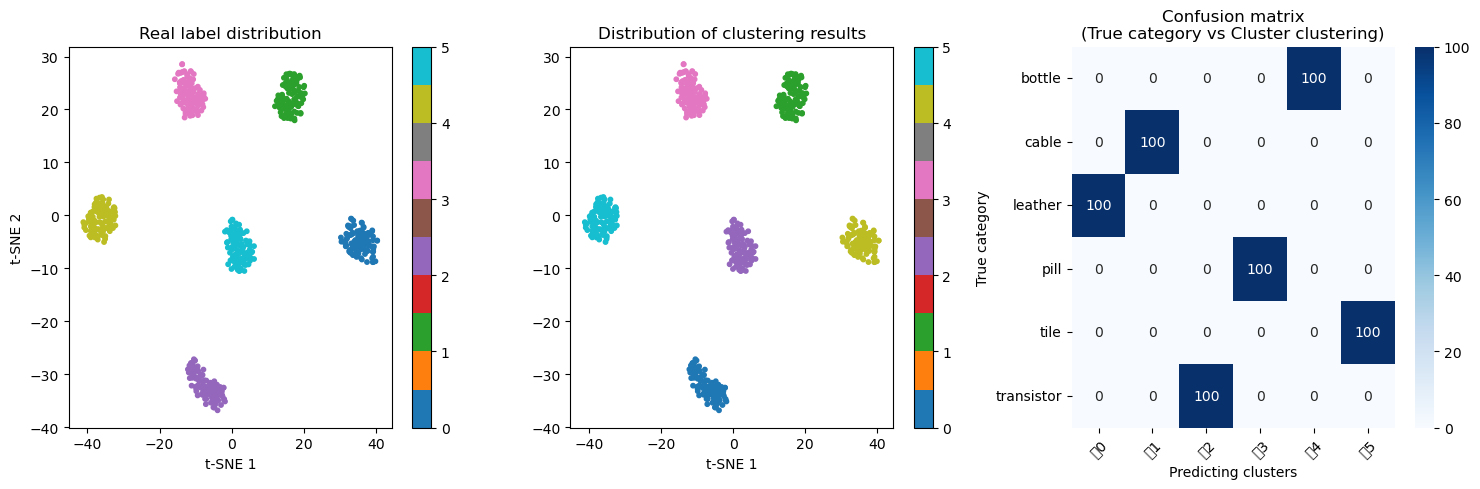

In [7]:
# 使用t-SNE降维可视化
print("正在进行t-SNE降维可视化...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

# 创建可视化图表
plt.figure(figsize=(15, 5))

# 子图1：真实标签可视化
plt.subplot(1, 3, 1)
scatter1 = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=true_labels_numeric, cmap='tab10', s=10)
plt.colorbar(scatter1)
plt.title('Real label distribution')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# 子图2：聚类结果可视化
plt.subplot(1, 3, 2)
scatter2 = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, cmap='tab10', s=10)
plt.colorbar(scatter2)
plt.title('Distribution of clustering results')
plt.xlabel('t-SNE 1')

# 子图3：混淆矩阵
plt.subplot(1, 3, 3)
cm = confusion_matrix(true_labels_numeric, cluster_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'簇{i}' for i in range(k)],
            yticklabels=unique_true_labels)
plt.title('Confusion matrix\n(True category vs Cluster clustering)')
plt.xlabel('Predicting clusters')
plt.ylabel('True category')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()